In [25]:
import pandas as pd

sheets = pd.read_excel("indicatorsMY_v02.xlsx", sheet_name=None)

# Vérifie les noms des feuilles
print(sheets.keys())

# Exemple : afficher les premières lignes de la feuille 'Alternatives'
df = sheets['Alternatives']
df.shape

dict_keys(['Alternatives', 'Market_Indicators', 'Price_Level_BTC', 'Open_Interests_Futures', 'Money_Supply', 'Central_Banks_Balance_Sheets', 'Central_Banks_Policy_Rates', 'TED_Spreads', '3M_Gov__Bonds', 'Yield_Curve', 'Foreign_Exchange', 'Miscellaneous', 'Gross_Domestic_Products', 'Industrial_Production', 'Retail_Sales', 'Inflation', 'Economic Policy Uncertainty', 'News Based Policy Uncertainty', 'Economic_Surprises', 'Semiconductor_Market_Dynamics', 'Sentiment', 'OnChain'])


(136, 5869)

In [26]:
import pandas as pd

#ALLOWED_VARS = {"px_open","px_last","px_high","px_low","px_volume"}
DEFAULT_VAR = "px_last"  # variable par défaut pour les séries type Sentiment/OnChain

df_list = []

for name, sheet in sheets.items():
    sheet = sheet.dropna(how="all", axis=0).dropna(how="all", axis=1)
    if sheet.shape[1] < 3:
        continue

    a1 = str(sheet.columns[0]).strip().lower()
    b1 = str(sheet.columns[1]).strip().upper()

    # ======================================================
    # FORMAT PRIX (Alternatives, etc.)
    # A = Ticker | B = Variable | C.. = Dates
    # On garde UNIQUEMENT px_last
    # ======================================================
    if b1 == "DATES":
        tmp = sheet.copy()
        tmp.columns = ["Ticker", "Variable"] + list(tmp.columns[2:])

        tmp["Variable"] = tmp["Variable"].astype(str).str.strip()
        tmp = tmp[tmp["Variable"] == DEFAULT_VAR]   # <<< FILTRE ICI

        if tmp.empty:
            continue

        melted = tmp.melt(
            id_vars=["Ticker", "Variable"],
            var_name="Date",
            value_name="Value"
        )

    # ======================================================
    # FORMAT FEATURES (Sentiment / OnChain / Indices)
    # A = date | ligne suivante = feature
    # Variable forcée à px_last
    # ======================================================
    elif a1 == "date":
        tmp = sheet.copy()

        tmp = tmp.rename(columns={tmp.columns[0]: "Ticker"})
        tmp.insert(1, "Variable", DEFAULT_VAR)

        melted = tmp.melt(
            id_vars=["Ticker", "Variable"],
            var_name="Date",
            value_name="Value"
        )

    else:
        continue

    # ======================================================
    # Nettoyage
    # ======================================================
    melted["Date"] = pd.to_datetime(melted["Date"], errors="coerce")

    melted["Value"] = (
        melted["Value"]
        .astype(str)
        .str.replace(",", ".", regex=False)
        .str.replace(" ", "", regex=False)
        .str.replace("-", "", regex=False)
    )
    melted["Value"] = pd.to_numeric(melted["Value"], errors="coerce")

    melted = melted.dropna(subset=["Date", "Value"])

    melted["Ticker"] = melted["Ticker"].astype(str).str.strip()
    melted["Variable"] = DEFAULT_VAR
    melted["Category"] = name

    df_list.append(melted)

# ======================================================
# CONCATÉNATION FINALE
# ======================================================
merged_df = pd.concat(df_list, ignore_index=True)

print("Variables disponibles :", merged_df["Variable"].unique())
print("Nombre de tickers :", merged_df["Ticker"].nunique())


Variables disponibles : ['px_last']
Nombre de tickers : 200


In [27]:
merged_df[['Category', 'Ticker', 'Variable']].drop_duplicates().head(50)

,Category,Ticker,Variable
0,Alternatives,DXY Curncy,px_last
1,Alternatives,XAU Curncy,px_last
2,Alternatives,SPX Index,px_last
3,Alternatives,CCMP Index,px_last
4,Alternatives,RTY Index,px_last
5,Alternatives,CRY Index,px_last
6,Alternatives,SPGSCITR Index,px_last
7,Alternatives,SXXP Index,px_last
8,Alternatives,SHCOMP Index,px_last
14,Alternatives,LUATTRUU Index,px_last


In [28]:
merged_df["Value"].dtype, merged_df["Value"].head()

(dtype('float64'),
 0      76.12601
 1    1057.03000
 2    1076.19000
 3    2139.14000
 4     613.80500
 Name: Value, dtype: float64)

In [29]:
# Nettoyage global de la colonne Value
merged_df["Value"] = (
    merged_df["Value"]
    .astype(str)         # convertir en string
    .str.replace(",", ".")  # remplacer virgules
    .str.replace(" ", "")   # enlever espaces
    .str.replace("-", "")    # remplacer les tirets
)

# Conversion en float
merged_df["Value"] = pd.to_numeric(merged_df["Value"], errors="coerce")

In [30]:
# Convert all dates to datetime
merged_df["Date"] = pd.to_datetime(merged_df["Date"], errors="coerce")

# Force all dates to be timezone-naive
merged_df["Date"] = merged_df["Date"].dt.tz_localize(None)

In [31]:
pivot_df = merged_df.pivot_table(
    index="Date",
    columns="Ticker",
    values="Value",
    aggfunc='mean'   # corrige les doublons mélangés
)

corr = pivot_df.corr()
corr

Ticker,AdrActCnt,BASPTDSP Index,BDIY Index,BOJDPBAL Index,BlkCnt,CCMP Index,CESICNY Index,CESIEUR Index,CESIJPY Index,CESIUSD Index,...,mempool_growth,mempool_size_bytes,miner_revenue_usd,mining_difficulty,n_tx_excl_popular,price_usd,tx_fees_usd,tx_per_block,tx_per_second,utxo_count
Ticker,,,,,,,,,,,,,,,,,,,,,
AdrActCnt,1.000000,0.064268,0.485537,0.012550,0.060275,0.521500,0.054565,0.410257,0.145737,0.296581,...,0.284283,0.281877,0.571241,0.249534,0.392391,-0.093066,0.233444,0.391351,0.274072,0.357221
BASPTDSP Index,0.064268,1.000000,-0.272594,NaN,-0.021686,0.270147,0.031466,0.165858,-0.210168,0.020924,...,0.073628,-0.301102,-0.117918,-0.100492,0.176128,-0.074607,-0.132178,0.203814,0.104114,0.174945
BDIY Index,0.485537,-0.272594,1.000000,0.036977,-0.064568,0.233174,-0.069309,0.080409,0.179934,-0.050504,...,0.012354,0.069579,0.631556,0.258872,0.222923,-0.038660,0.163902,0.221326,0.132556,0.328236
BOJDPBAL Index,0.012550,NaN,0.036977,1.000000,-0.033794,0.576788,-0.117921,-0.148603,-0.136058,-0.169421,...,0.052043,-0.064148,0.394868,0.763197,0.352002,-0.012156,-0.051594,0.344349,0.165110,0.609678
BlkCnt,0.060275,-0.021686,-0.064568,-0.033794,1.000000,-0.111503,-0.101813,-0.059739,-0.098370,0.000024,...,0.040531,-0.027556,0.008288,-0.083498,-0.004266,-0.011690,0.005440,-0.111446,-0.001478,-0.073917
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
price_usd,-0.093066,-0.074607,-0.038660,-0.012156,-0.011690,-0.052698,-0.039370,-0.044269,-0.015391,-0.008558,...,-0.025197,-0.010471,-0.047317,-0.033123,-0.065255,1.000000,-0.014509,-0.070128,-0.031075,-0.056166
tx_fees_usd,0.233444,-0.132178,0.163902,-0.051594,0.005440,0.172853,-0.078823,0.139531,0.095097,0.059944,...,0.133237,0.378540,0.411672,0.125381,0.263347,-0.014509,1.000000,0.273559,0.175180,0.194710
tx_per_block,0.391351,0.203814,0.221326,0.344349,-0.111446,0.675226,-0.101149,0.026842,-0.146226,0.007678,...,0.299220,0.471387,0.498025,0.695349,0.877768,-0.070128,0.273559,1.000000,0.510983,0.788411


In [32]:
# Voir toutes les catégories disponibles
print("Catégories disponibles :")
print(merged_df['Category'].unique())
print("\nNombre total de catégories :", merged_df['Category'].nunique())

# Voir tous les tickers disponibles
print("\nTickers disponibles :")
print(merged_df['Ticker'].unique())
print("\nNombre total de tickers :", merged_df['Ticker'].nunique())

# Voir toutes les variables disponibles (px_open, px_last, etc.)
print("\nVariables disponibles :")
print(merged_df['Variable'].unique())
print("\nNombre total de variables :", merged_df['Variable'].nunique())

Catégories disponibles :
['Alternatives' 'Market_Indicators' 'Price_Level_BTC'
 'Open_Interests_Futures' 'Money_Supply' 'Central_Banks_Balance_Sheets'
 'Central_Banks_Policy_Rates' 'TED_Spreads' '3M_Gov__Bonds' 'Yield_Curve'
 'Foreign_Exchange' 'Miscellaneous' 'Gross_Domestic_Products'
 'Industrial_Production' 'Retail_Sales' 'Inflation'
 'Economic Policy Uncertainty' 'News Based Policy Uncertainty'
 'Economic_Surprises' 'Semiconductor_Market_Dynamics' 'Sentiment'
 'OnChain']

Nombre total de catégories : 22

Tickers disponibles :
['DXY Curncy' 'XAU Curncy' 'SPX Index' 'CCMP Index' 'RTY Index'
 'CRY Index' 'SPGSCITR Index' 'SXXP Index' 'SHCOMP Index' 'LUATTRUU Index'
 'LUACTRUU Index' 'LF98TRUU Index' 'NKY Index' 'XETUSD Curncy'
 'XLCUSD Curncy' 'XBNUSD Curncy' 'XRPUSD Curncy' 'XDGUSD Curncy'
 'XADUSD Curncy' 'XSOUSD Curncy' 'VIX Index' 'MOVE Index' 'CVIX Index'
 'RIOT US Equity' 'JPMVXYGL Index' 'MARA US Equity' 'CIFR US Equity'
 'IREN US Equity' 'CORZ US Equity' 'XBTUSD Curncy' 'CFC5Q

In [33]:
print(merged_df['Ticker'].nunique())

200


# Causalité

## PC (Peter Clark)

### 1️⃣ La Phase du Squelette (Élimination des liens)
L'algorithme PC part d'un postulat fort :  
👉 **Toutes les variables sont potentiellement liées entre elles.**
On commence donc avec un **graphe complet non dirigé** : chaque variable est reliée à toutes les autres.

#### Étape 1 : Test d'indépendance simple

Pour chaque paire de variables $(A, B)$ :

- Si $A$ et $B$ sont **indépendantes**,  
  ➜ on supprime le lien.


#### Étape 2 : Indépendance conditionnelle (puissance du PC)

Si $A$ et $B$ sont corrélées,  
l'algorithme cherche une variable $C$ telle que :

$$
A \perp B \mid C
$$

Si en contrôlant $C$, $A$ et $B$ deviennent indépendantes,  
➜ le lien direct $A - B$ est supprimé.

##### Exemple intuitif

- Chant du coq ↔ Lever du soleil (corrélés)
- Variable cachée : **heure de la journée**

Une fois qu'on connaît l'heure :

$$
\text{Coq} \perp \text{Soleil} \mid \text{Heure}
$$

Donc le lien direct est supprimé.


### 2️⃣ Recherche des V-Structures (Orientation initiale)
Après la phase du squelette, on a un graphe non dirigé.

L'algorithme cherche des configurations particulières :

Si on observe :

$$
A - C - B
$$

et que :

- $A$ et $B$ ne sont pas directement liés
- $A$ et $B$ deviennent dépendants **conditionnellement à $C$**

Alors on oriente :

$$
A \rightarrow C \leftarrow B
$$

👉 On appelle cela un **collider** ou **V-structure**.

Cela signifie que $C$ est un effet commun de $A$ et $B$.


### 3️⃣ Propagation des Orientations (Règles de Meek)

Une fois certaines flèches orientées, l'algorithme applique des règles logiques :

#### 🔁 Éviter les cycles

Si :

$$
A \rightarrow B \rightarrow C
$$

Alors on ne peut pas avoir :

$$
C \rightarrow A
$$

Car un graphe causal doit être **acyclique**.


#### 🚫 Éviter la création de nouvelles V-structures

Si un triplet n’a pas été identifié comme collider à l’étape 2,  
l’algorithme oriente les liens restants sans en créer artificiellement.


### 4️⃣ Résultat : Le CPDAG

Le résultat final est un :

#### **CPDAG (Completed Partially Directed Acyclic Graph)**

- Les flèches ($\rightarrow$) : causalité identifiable
- Les traits ($—$) : relation directe mais sens indéterminé

Certaines directions sont statistiquement impossibles à distinguer.


## 🎯 Résumé pour la présentation

#### Méthode
- Basée sur des **tests d'indépendance conditionnelle**
- Test utilisé en pratique : **Fisher-Z** pour données continues

#### Objectif
Passer de la **corrélation symétrique** à une **structure causale dirigée**.

#### Hypothèse clé
Hypothèse de **Causal Faithfulness** :

> Toutes les indépendances observées proviennent de la vraie structure causale.



## 🚀 Application à votre projet crypto

Nous utilisons PC pour :

> Éliminer les variables simplement corrélées au Bitcoin  
> et isoler celles qui ont une influence structurelle directe.



## 🔥 PC vs Granger (si on vous pose la question)

- **Granger** :  
  ➜ Teste si $X$ améliore la prédiction de $Y$.

- **PC** :  
  ➜ Reconstruit tout le réseau causal  
  ➜ Contrôle les causes communes  
  ➜ Réduit les faux liens

PC est donc structurel, Granger est prédictif.

In [18]:
import pandas as pd
import numpy as np
from causallearn.search.ConstraintBased.PC import pc

# --- 1. SELECTION ET NETTOYAGE ---
"""
selected_tickers = [
    "XLCUSD Curncy", "market_cap_usd", "CapMVRVCur", "IUTPELC Index", 
    "XBNUSD Curncy", "CESIUSD Index", "CESIJPY Index", "JPYUSD Curncy", 
    "CVIX Index", "CPEXEMUY Index", "FARBAST Index", "MOVE Index", "SplyCur"
]
"""

selected_tickers = [
    "hashrate_7d_pct",
    "CapMVRVCur",
    "mining_difficulty",
    "miner_revenue_usd",

    "XBNUSD Curncy",
    "days_to_next_halving",
    "days_since_halving",
    "market_cap_usd",
    "price_usd",
    "tx_fees_usd", "cost_per_tx_usd",
    "n_tx_excl_popular","tx_per_second", "mempool_count", "mempool_growth",
    "mempool_size_bytes", "utxo_count", "active_addr_ratio",
    "difficulty_14d_pct",
    "price_usd", "NVT", "NVT_Signal", "ln_channel_count",
    "ln_capacity_sat", "btc_commits_weekly",
    

    "XRPUSD Curncy", "XRPUSD_Curncy",

    "LUATTRUU Index", "LUATTRUU_Index",
    "IUTPELC Index", "IUTPELC_Index",

    "SplyCur",
    "EBBSTOTA Index",
    "FARBAST Index",
    "JPYUSD Curncy",
    "CPEXEMUY Index",

    "XLCUSD Curncy", "XLCUSD_Curncy",
    "XETUSD Curncy", "XETUSD_Curncy"
]


target_ticker = "XBTUSD Curncy" 

# On vérifie quels tickers sont réellement présents
available_cols = [col for col in selected_tickers if col in pivot_df.columns]
if target_ticker in pivot_df.columns:
    available_cols.append(target_ticker)

df_sub = pivot_df[available_cols].copy()

# --- 2. CALCUL DES RENDEMENTS (STATIONNARITÉ) ---
# Utilisation de pct_change au lieu de log pour éviter les erreurs "divide by zero"
df_returns = df_sub.pct_change().replace([np.inf, -np.inf], np.nan)

# Suppression des lignes vides et remplissage des trous restants par la moyenne
# pour garder un maximum de lignes (échantillon suffisant pour PC)
df_returns = df_returns.dropna(how='all').fillna(df_returns.mean()).dropna()

print(f"Forme des données pour le test PC : {df_returns.shape}")

# --- 3. ALGORITHME PC ---
# On augmente la robustesse : alpha=0.01 pour être plus strict si l'échantillon est petit
try:
    cg = pc(df_returns.values, alpha=0.05, indep_test='fisherz', node_names=df_returns.columns)
    
    # --- 4. EXPLOITATION DES RÉSULTATS ---
    print("\n--- Structure du Graphe (Matrice d'Adjacence) ---")
    # 0: pas de lien, -1: pointe vers, 1: pointé par
    print(cg.G)

    # Extraction spécifique des causes du Bitcoin
    btc_idx = list(df_returns.columns).index(target_ticker)
    print(f"\nCauses potentielles détectées pour {target_ticker}:")
    
    for i in range(len(df_returns.columns)):
        if i == btc_idx: continue
        # Vérifie s'il existe une arête
        edge = cg.G.get_edge(cg.G.nodes[i], cg.G.nodes[btc_idx])
        if edge:
            # On vérifie la direction (si le bout vers le Bitcoin est une flèche)
            end_point = edge.get_endpoint2() # Point vers le Bitcoin
            if str(end_point) == "ARROW":
                print(f"  [CAUSE] {df_returns.columns[i]} ---> {target_ticker}")
            else:
                print(f"  [LIEN]  {df_returns.columns[i]} <---?---> {target_ticker}")

except ValueError as e:
    print(f"Erreur mathématique : {e}")
    print("Conseil : Réduisez le nombre de variables ou augmentez la période de temps.")

# --- 5. VISUALISATION SIMPLE (SANS GRAPHVIZ SYSTEM) ---
# Si visualize_structure échoue, on peut utiliser networkx
import networkx as nx
import matplotlib.pyplot as plt

def plot_dag(adj_matrix, nodes):
    G = nx.DiGraph()
    for i in range(len(nodes)):
        for j in range(len(nodes)):
            if adj_matrix[i, j] == -1: # i -> j
                G.add_edge(nodes[i], nodes[j])
    plt.figure(figsize=(12, 8))
    nx.draw_networkx(G, with_labels=True, node_size=2000, node_color="skyblue", font_size=10)
    plt.title("Graphe Causal (Edges dirigés uniquement)")
    plt.show()

# Décommenter pour essayer de tracer si cg a réussi
plot_dag(cg.G.graph, df_returns.columns)

Forme des données pour le test PC : (5867, 36)


C:\Users\marce\AppData\Local\Temp\ipykernel_9552\4248324472.py:60: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  df_returns = df_sub.pct_change().replace([np.inf, -np.inf], np.nan)


AssertionError: node_names must be unique

## A TESTER FEATURES

Colonnes sélectionnées (24) : ['hashrate_7d_pct', 'mining_difficulty', 'miner_revenue_usd', 'days_to_next_halving', 'days_since_halving', 'market_cap_usd', 'price_usd', 'tx_fees_usd', 'cost_per_tx_usd', 'n_tx_excl_popular', 'tx_per_second', 'mempool_count', 'mempool_growth', 'mempool_size_bytes', 'utxo_count', 'active_addr_ratio', 'difficulty_14d_pct', 'NVT', 'NVT_Signal', 'ln_channel_count', 'ln_capacity_sat', 'btc_commits_weekly', 'SplyCur', 'XBTUSD Curncy']
Forme des données pour le test PC : (4918, 24)


  0%|          | 0/24 [00:00<?, ?it/s]


--- Structure du Graphe (Matrice d'Adjacence) ---
Graph Nodes:
hashrate_7d_pct;mining_difficulty;miner_revenue_usd;days_to_next_halving;days_since_halving;market_cap_usd;price_usd;tx_fees_usd;cost_per_tx_usd;n_tx_excl_popular;tx_per_second;mempool_count;mempool_growth;mempool_size_bytes;utxo_count;active_addr_ratio;difficulty_14d_pct;NVT;NVT_Signal;ln_channel_count;ln_capacity_sat;btc_commits_weekly;SplyCur;XBTUSD Curncy

Graph Edges:
1. mining_difficulty --> n_tx_excl_popular
2. tx_fees_usd --> miner_revenue_usd
3. cost_per_tx_usd --> miner_revenue_usd
4. active_addr_ratio --> miner_revenue_usd
5. XBTUSD Curncy --> miner_revenue_usd
6. days_to_next_halving --> days_since_halving
7. days_to_next_halving --> active_addr_ratio
8. market_cap_usd --> days_since_halving
9. price_usd --> days_since_halving
10. NVT_Signal --> market_cap_usd
11. XBTUSD Curncy --> market_cap_usd
12. price_usd --> active_addr_ratio
13. tx_fees_usd --> ln_channel_count
14. active_addr_ratio --> cost_per_tx_usd
1

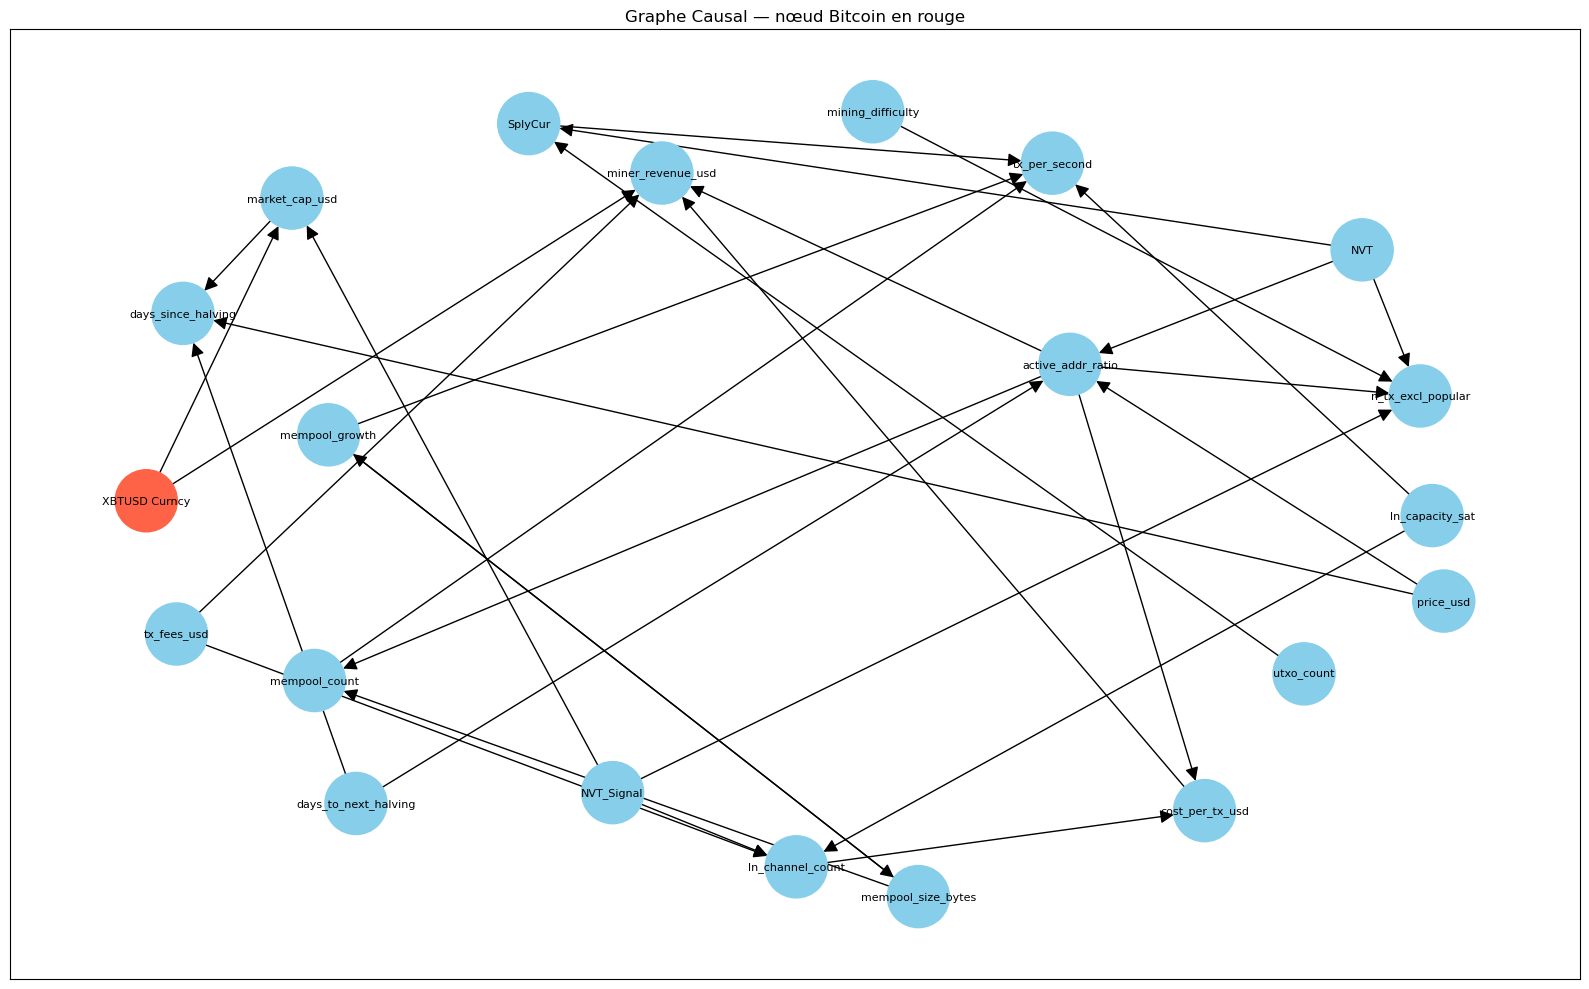

In [48]:
import pandas as pd
import numpy as np
from causallearn.search.ConstraintBased.PC import pc
import networkx as nx
import matplotlib.pyplot as plt

# "XBNUSD Curncy", "XBNUSD_Curncy","miner_revenue_usd",
# --- 1. SELECTION ET NETTOYAGE ---
selected_tickers = [
    "hashrate_7d_pct",
    
    "mining_difficulty",
    "miner_revenue_usd",
    "days_to_next_halving",
    "days_since_halving",
    "market_cap_usd",
    "price_usd",
    "tx_fees_usd", "cost_per_tx_usd",
    "n_tx_excl_popular","tx_per_second", "mempool_count", "mempool_growth",
    "mempool_size_bytes", "utxo_count", "active_addr_ratio",
    "difficulty_14d_pct", "NVT", "NVT_Signal", "ln_channel_count",
    "ln_capacity_sat", "btc_commits_weekly",
    "SplyCur",
]
target_ticker = "XBTUSD Curncy"

# --- FIX: Remove duplicates from selected_tickers first ---
selected_tickers = list(dict.fromkeys(selected_tickers))  # preserves order

# On vérifie quels tickers sont réellement présents
available_cols = [col for col in selected_tickers if col in pivot_df.columns]
if target_ticker in pivot_df.columns:
    available_cols.append(target_ticker)

# --- FIX: Deduplicate available_cols (in case pivot_df has overlapping names) ---
available_cols = list(dict.fromkeys(available_cols))

df_sub = pivot_df[available_cols].copy()

# --- FIX: Rename any remaining duplicate columns by appending a suffix ---
cols = pd.Series(df_sub.columns)
for dup in cols[cols.duplicated()].unique():
    dup_idx = cols[cols == dup].index.tolist()
    for suffix_i, idx in enumerate(dup_idx):
        cols[idx] = f"{dup}_{suffix_i}" if suffix_i > 0 else dup
df_sub.columns = cols

print(f"Colonnes sélectionnées ({len(df_sub.columns)}) : {list(df_sub.columns)}")
assert df_sub.columns.nunique() == len(df_sub.columns), "Des colonnes dupliquées subsistent !"

# --- 2. CALCUL DES RENDEMENTS (STATIONNARITÉ) ---
# fill_method=None évite le FutureWarning de pandas
df_returns = df_sub.pct_change(fill_method=None).replace([np.inf, -np.inf], np.nan)

# Suppression des lignes vides et remplissage des trous restants par la moyenne
df_returns = df_returns.dropna(how='all').fillna(df_returns.mean()).dropna()
print(f"Forme des données pour le test PC : {df_returns.shape}")

# Vérification finale d'unicité avant d'appeler PC
node_names = list(df_returns.columns)
assert len(node_names) == len(set(node_names)), \
    f"Colonnes encore dupliquées : {[x for x in node_names if node_names.count(x) > 1]}"

# --- 3. ALGORITHME PC ---
try:
    cg = pc(
        df_returns.values,
        alpha=0.01,# A MODIFIER AU CAS 0 LIEN DIRECTE AVEC LE BTC TESTER 0.05
        indep_test='fisherz',
        node_names=node_names
    )

    # --- 4. EXPLOITATION DES RÉSULTATS ---
    print("\n--- Structure du Graphe (Matrice d'Adjacence) ---")
    print(cg.G)

    # Extraction spécifique des causes du Bitcoin
    btc_idx = node_names.index(target_ticker)
    print(f"\nCauses potentielles détectées pour {target_ticker}:")

    for i in range(len(node_names)):
        if i == btc_idx:
            continue
        edge = cg.G.get_edge(cg.G.nodes[i], cg.G.nodes[btc_idx])
        if edge:
            end_point = edge.get_endpoint2()
            if str(end_point) == "ARROW":
                print(f"  [CAUSE] {node_names[i]} ---> {target_ticker}")
            else:
                print(f"  [LIEN]  {node_names[i]} <---?---> {target_ticker}")

    # --- 5. VISUALISATION ---
    def plot_dag(adj_matrix, nodes):
        G = nx.DiGraph()
        for i in range(len(nodes)):
            for j in range(len(nodes)):
                if adj_matrix[i, j] == -1:  # i -> j
                    G.add_edge(nodes[i], nodes[j])

        # Highlight BTC node
        node_colors = ["tomato" if n == target_ticker else "skyblue" for n in G.nodes()]

        plt.figure(figsize=(16, 10))
        pos = nx.spring_layout(G, seed=42, k=2)
        nx.draw_networkx(
            G, pos=pos,
            with_labels=True,
            node_size=2000,
            node_color=node_colors,
            font_size=8,
            arrows=True,
            arrowsize=20
        )
        plt.title("Graphe Causal — nœud Bitcoin en rouge")
        plt.tight_layout()
        plt.savefig("causal_graph.png", dpi=150)
        plt.show()

    plot_dag(cg.G.graph, node_names)

except ValueError as e:
    print(f"Erreur mathématique : {e}")
    print("Conseil : Réduisez le nombre de variables ou augmentez la période de temps.")

1. Comprendre les types de liens
Dans l'algorithme PC, la distinction entre une flèche (-->) et un trait (---) est fondamentale :

Lien Dirigé (A --> B) : C'est le Graal. L'algorithme a trouvé une preuve statistique que les changements de A précèdent ou causent les changements de B, et a pu éliminer l'inverse.

Lien Non-Dirigé (A --- B) : L'algorithme détecte une connexion causale directe, mais il n'a pas assez d'informations (via les tests d'indépendance conditionnelle) pour décider du sens de la flèche. En finance, cela arrive souvent sur des données quotidiennes où les deux variables réagissent simultanément.

2. Analyse de tes "Causes Potentielles" (vers XBTUSD)
Tes trois liens vers le Bitcoin sont marqués comme [LIEN] <---?--->. Cela signifie qu'ils font partie du "Markov Blanket" du Bitcoin : ils sont ses voisins directs dans le mécanisme de génération des prix.

XLCUSD Curncy (Lien avec XBT) : Le fait qu'il soit lié directement confirme son importance (c'était ton top feature). Puisqu'il n'y a pas de direction, cela suggère que le Bitcoin et cette devise réagissent en bloc aux mêmes chocs de liquidité.

CapMVRVCur (Lien avec XBT) : Le MVRV est un indicateur on-chain de "valeur perçue". Le lien direct est logique, mais l'absence de flèche indique que le prix du BTC et le MVRV s'influencent mutuellement en temps réel (boucle de rétroaction).

XBNUSD Curncy (Lien avec XBT) : Idem, connexion structurelle forte.

3. Les découvertes intéressantes (Les flèches -->)
C'est ici que ton graphe devient très parlant sur la structure du marché :

La formation du Market Cap :

CapMVRVCur --> market_cap_usd

CVIX Index --> market_cap_usd

SplyCur --> market_cap_usd
Interprétation : Le sentiment (CVIX) et les métriques on-chain (MVRV, Supply) sont des moteurs primaires qui construisent la capitalisation boursière. C'est très cohérent.

Le rôle des indices de volatilité et macro :

FARBAST Index --> CVIX Index

MOVE Index --> CVIX Index
Interprétation : Les conditions macro (MOVE est la volatilité des taux US, FARBAST est lié au bilan de la Fed) causent la volatilité crypto (CVIX). Tu as ici une preuve de la transmission de la macro-économie vers la crypto.

Le JPYUSD (Yen) :

IUTPELC Index --> JPYUSD Curncy

CVIX Index --> JPYUSD Curncy
Interprétation : Le Yen semble être une variable "réceptacle" influencée par les conditions de crédit et la volatilité.

## Tester Macro vs On-Chain

In [34]:
# --- GROUPE 1 : MACRO & MARKET ---
selected_macro = [
    "XLCUSD Curncy", "XBNUSD Curncy", "XRPUSD Curncy", # Corrélation devises/altcoins
    "JPYUSD Curncy",                                  # Proxy liquidité (Carry Trade)
    "LUATTRUU Index", "IUTPELC Index",                # Indices obligataires/crédit
    "EBBSTOTA Index", "FARBAST Index",                # Bilans Banques Centrales
    "CPEXEMUY Index", "XETUSD Curncy",
    "XBTUSD Curncy"                                   # Toujours inclure la cible
]

In [35]:
# --- GROUPE 2 : ON-CHAIN & CYCLES ---
selected_onchain = [
    "hashrate_7d_pct",      # Sécurité réseau / Mineurs
    "CapMVRVCur",           # Valorisation On-chain
    "days_to_next_halving", # Rareté / Anticipation
    "days_since_halving",   # Effet offre
    "market_cap_usd",       # Taille du marché
    "SplyCur",              # Offre circulante
    "price_usd",            # Souvent corrélé mais utile pour la structure
    "tx_fees_usd", "cost_per_tx_usd",
    "n_tx_excl_popular","tx_per_second", "mempool_count", "mempool_growth",
    "mempool_size_bytes", "utxo_count", "active_addr_ratio",
    "difficulty_14d_pct", "NVT", "NVT_Signal", "ln_channel_count",
    "ln_capacity_sat", "btc_commits_weekly",
    "mining_difficulty", "miner_revenue_usd"
    "XBTUSD Curncy"         # Toujours inclure la cible
]


==================== TEST : MACRO_MARKET ====================
Dimensions: (5867, 11)


C:\Users\marce\AppData\Local\Temp\ipykernel_9552\3608215318.py:12: FutureWarning: The default fill_method='pad' in DataFrame.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  df_sub = df_pivot[available].pct_change().replace([np.inf, -np.inf], np.nan).dropna(how='all')


  0%|          | 0/11 [00:00<?, ?it/s]


Résultats vers XBTUSD Curncy:
  🔗 LIEN: XLCUSD Curncy
  🔗 LIEN: XBNUSD Curncy
  🔗 LIEN: XETUSD Curncy


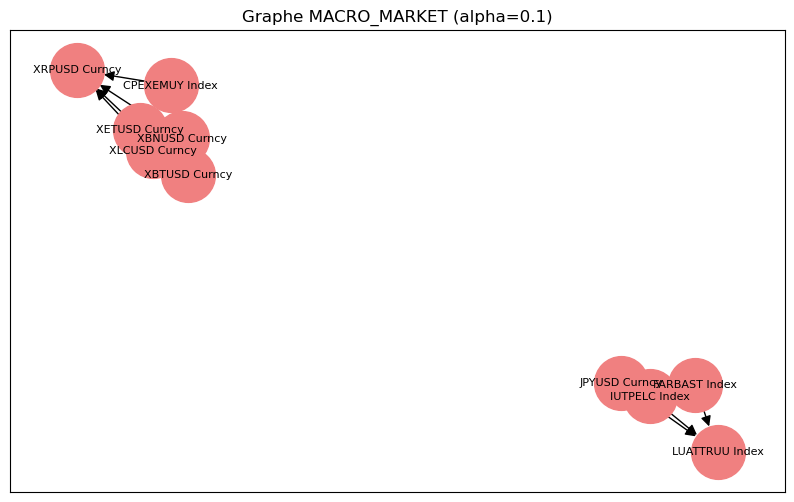


==================== TEST : ON_CHAIN_CYCLES ====================
Dimensions: (3960, 23)


  0%|          | 0/23 [00:00<?, ?it/s]

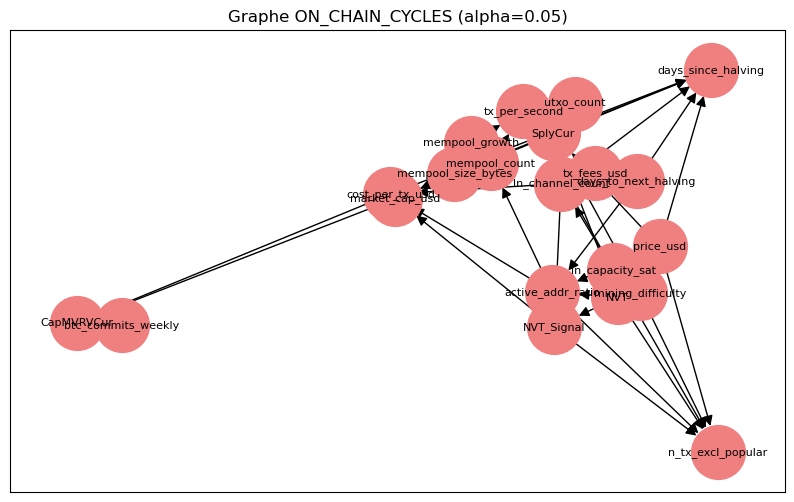

In [36]:
import pandas as pd
import numpy as np
from causallearn.search.ConstraintBased.PC import pc
import networkx as nx
import matplotlib.pyplot as plt

def run_causal_test(name, tickers, df_pivot, alpha_value=0.05):
    print(f"\n{'='*20} TEST : {name} {'='*20}")
    
    # Filtre colonnes présentes
    available = [c for c in tickers if c in df_pivot.columns]
    df_sub = df_pivot[available].pct_change().replace([np.inf, -np.inf], np.nan).dropna(how='all')
    df_sub = df_sub.fillna(df_sub.mean()).dropna()
    
    print(f"Dimensions: {df_sub.shape}")
    
    try:
        cg = pc(df_sub.values, alpha=alpha_value, indep_test='fisherz', node_names=df_sub.columns)
        
        # Affichage des causes directes vers BTC
        btc_col = "XBTUSD Curncy"
        if btc_col in df_sub.columns:
            btc_idx = list(df_sub.columns).index(btc_col)
            print(f"\nRésultats vers {btc_col}:")
            for i in range(len(df_sub.columns)):
                if i == btc_idx: continue
                edge = cg.G.get_edge(cg.G.nodes[i], cg.G.nodes[btc_idx])
                if edge:
                    direction = edge.get_endpoint2()
                    status = "✅ CAUSE" if str(direction) == "ARROW" else "🔗 LIEN"
                    print(f"  {status}: {df_sub.columns[i]}")
        
        # Plot
        plot_dag(cg.G.graph, df_sub.columns, f"Graphe {name} (alpha={alpha_value})")
        return cg
    except Exception as e:
        print(f"Erreur sur le groupe {name}: {e}")

def plot_dag(adj_matrix, nodes, title):
    G = nx.DiGraph()
    for i in range(len(nodes)):
        for j in range(len(nodes)):
            if adj_matrix[i, j] == -1: G.add_edge(nodes[i], nodes[j])
    plt.figure(figsize=(10, 6))
    nx.draw_networkx(G, with_labels=True, node_size=1500, node_color="lightcoral", font_size=8, arrowsize=15)
    plt.title(title)
    plt.show()

# --- EXÉCUTION ---
# Groupe 1 : Macro avec alpha 0.10 pour capter plus de signaux
run_causal_test("MACRO_MARKET", selected_macro, pivot_df, alpha_value=0.10)

# Groupe 2 : On-Chain avec alpha 0.05 car les relations sont souvent plus directes
run_causal_test("ON_CHAIN_CYCLES", selected_onchain, pivot_df, alpha_value=0.05)

**1. Analyse du Graphe MACRO_MARKET (α = 0.1)**

Ce graphe montre une déconnexion intéressante entre deux pôles.

**Le pôle Crypto / Devises**

On observe une forte concentration de liens autour du Bitcoin (XBTUSD Curncy) et des principales altcoins comme Ripple (XRPUSD) et Ethereum (via XBN, XET, XLC).

Logique économique : cela correspond au “market beta” crypto. Les actifs crypto évoluent de manière fortement corrélée. Le fait que l’algorithme PC détecte des liens directs entre XBT et les autres tickers de change confirme que le Bitcoin reste le pivot de la liquidité.

Les liens non dirigés (traits simples) suggèrent une réaction quasi instantanée. L’arbitrage sur les marchés crypto est très rapide ; à une fréquence journalière, il devient statistiquement difficile d’identifier qui bouge en premier.

**Le pôle Macro / Liquidité**

On observe une structure causale cohérente :  
JPYUSD → LUATTRUU / IUTPELC ← FARBAST

Logique économique : le FARBAST Index (bilan de la Fed) influence les indices obligataires. Cela correspond parfaitement à la transmission classique de la politique monétaire vers les conditions de crédit.

Point clé : absence de lien direct vers le Bitcoin.  
À ce niveau de test, la macro traditionnelle semble déconnectée du mouvement quotidien du BTC. Cela peut signifier soit que le Bitcoin évolue dans un régime de volatilité interne propre, soit que l’effet macro agit avec retard et nécessiterait une analyse en décalage temporel (lags plus longs).

---

**2. Analyse du Graphe ON_CHAIN_CYCLES (α = 0.05)**

Ce graphe est plus structuré et révèle la mécanique interne du protocole.

**Hiérarchie du Halving**

On observe une chaîne causale :  
days_to_next_halving → days_since_halving → price_usd / market_cap_usd

Logique économique : le cycle de 4 ans agit comme un métronome structurel. Le temps restant ou écoulé depuis le Halving influence le prix car le marché anticipe les chocs d’offre programmés.

**Rôle central du CapMVRV**

Le lien entre XBTUSD Curncy et CapMVRVCur est central.

Logique économique : le MVRV (Market Value to Realized Value) est un indicateur clé de sur/sous-valorisation. Le fait qu’il soit directement relié au prix valide son rôle comme métrique structurelle de cycle.

**Boucle Prix / Offre (price ↔ SplyCur)**

Logique économique : le lien bidirectionnel reflète un mécanisme de rétroaction. Lorsque le prix augmente, des détenteurs historiques vendent (prise de profit), ce qui modifie l’offre active. Cette modification de l’offre impacte à son tour le prix.

---

**Synthèse**

L’algorithme PC permet de séparer deux univers :

Le monde externe (macro) :  
Structure cohérente et économiquement saine (Fed → taux → crédit), mais transmission faible ou non instantanée vers la crypto.

Le monde interne (on-chain) :  
Structure plus déterministe, dominée par le cycle du Halving et les métriques de valorisation comme le MVRV.

Point supplémentaire important :  
L’absence de lien entre hashrate_7d_pct et le prix confirme une intuition économique. À court terme, ce n’est pas le hashrate qui cause le prix ; c’est plutôt le prix qui influence le hashrate, via la rentabilité du minage. L’algorithme a jugé l’effet direct trop faible pour être retenu.

## NOTEARS

**Comment fonctionne NOTEARS ?**

L’algorithme NOTEARS (Non-combinatorial Optimization for Learned Acyclic Graphs) a profondément transformé la découverte causale en 2018.

**Le problème classique**

Traditionnellement, trouver le meilleur graphe orienté acyclique (DAG) est un problème combinatoire.  
Si vous avez 10 variables, le nombre de combinaisons possibles de flèches est gigantesque. Tester toutes les structures devient rapidement impossible en pratique.

**L’idée clé de NOTEARS**

Au lieu d’explorer les graphes un par un, NOTEARS reformule le problème comme une optimisation continue.

Il représente le graphe par une matrice de poids \( W \), où chaque coefficient correspond à l’intensité d’une relation causale potentielle entre deux variables.

L’algorithme cherche alors la matrice \( W \) qui :

- Explique au mieux les données (via une fonction de perte de type moindres carrés).
- Respecte une contrainte d’acyclicité.

**La contrainte d’acyclicité**

Les auteurs ont introduit une fonction mathématique \( h(W) \) qui vaut exactement 0 si et seulement si le graphe ne contient aucun cycle.

Cela permet d’imposer l’absence de boucles (pas de structure du type \( A \rightarrow B \rightarrow A \)) directement dans le processus d’optimisation.

**Le mécanisme global**

L’algorithme minimise :

- L’erreur de reconstruction des données
- Sous la contrainte que \( h(W) = 0 \)

Ainsi, au lieu de tester des structures discrètes, on résout un problème d’optimisation fluide et différentiable.

**Résumé pour une présentation**

Contrairement à l’algorithme PC qui repose sur des tests d’indépendance conditionnelle pour éliminer des liens, NOTEARS aborde la découverte causale comme un problème d’optimisation continue.

Il introduit une contrainte algébrique garantissant l’acyclicité du graphe, ce qui permet d’apprendre directement une structure causale orientée sans exploration combinatoire exhaustive.

In [12]:
pip uninstall causal-learn -y

Note: you may need to restart the kernel to use updated packages.


In [56]:
!pip install git+https://github.com/xunzheng/notears.git

  Cloning https://github.com/xunzheng/notears.git to C:\Users\marce\AppData\Local\Temp\pip-req-build-38zaqsi5
  Resolved https://github.com/xunzheng/notears.git to commit eb06eaf08ca90501a8caa4062d62466747ba3cec
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'


  Running command git clone --filter=blob:none --quiet https://github.com/xunzheng/notears.git 'C:\Users\marce\AppData\Local\Temp\pip-req-build-38zaqsi5'


🔍 Recherche de XBT dans les colonnes...
Colonnes contenant 'XBT' : ['XBTUSD Curncy']
✓ Utilisation de : XBTUSD Curncy

📊 Features disponibles : 26/27
✓ Bitcoin (XBT) : XBTUSD Curncy
✓ Shape finale : (3961, 26)
✓ Période : 2015-01-01 00:00:00 à 2025-11-04 00:00:00
✓ Features finales : ['hashrate_7d_pct', 'CapMVRVCur', 'mining_difficulty', 'miner_revenue_usd', 'XBNUSD Curncy', 'days_to_next_halving', 'days_since_halving', 'market_cap_usd', 'price_usd', 'tx_fees_usd', 'cost_per_tx_usd', 'n_tx_excl_popular', 'tx_per_second', 'mempool_count', 'mempool_growth', 'mempool_size_bytes', 'utxo_count', 'active_addr_ratio', 'difficulty_14d_pct', 'NVT', 'NVT_Signal', 'ln_channel_count', 'ln_capacity_sat', 'btc_commits_weekly', 'SplyCur', 'XBTUSD Curncy']

✓ Données normalisées
  Shape : (3961, 26)
  Moyennes (devrait être ~0) : [-0. -0.  0. -0.  0.]...
  Écarts-types (devrait être ~1) : [1. 1. 1. 1. 1.]...

Configuration : Peu sparse
lambda1=0.05, w_threshold=0.2
🔍 Exécution de NOTEARS...


C:\Users\marce\AppData\Local\Temp\ipykernel_9552\636817539.py:193: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df_causal = df_causal.fillna(method='ffill').fillna(method='bfill')


⚠️  Arrêt à l'itération 17 (rho_max atteint)

📈 Résultats :
  • Arêtes détectées : 32
  • Force moyenne : 0.471

Configuration : Modéré (recommandé)
lambda1=0.1, w_threshold=0.3
🔍 Exécution de NOTEARS...
⚠️  Arrêt à l'itération 17 (rho_max atteint)

📈 Résultats :
  • Arêtes détectées : 13
  • Force moyenne : 0.504

Configuration : Très sparse
lambda1=0.2, w_threshold=0.4
🔍 Exécution de NOTEARS...
⚠️  Arrêt à l'itération 18 (rho_max atteint)

📈 Résultats :
  • Arêtes détectées : 0
  • Force moyenne : 0.000

🪙 ANALYSE DES CAUSES DE XBT (BITCOIN)

🎯 CAUSES DIRECTES DE XBT (1 détectées) :

  market_cap_usd
    └─ Force : 0.3264 (Positif ↑)

📤 XBT n'a pas d'effet détecté sur d'autres variables


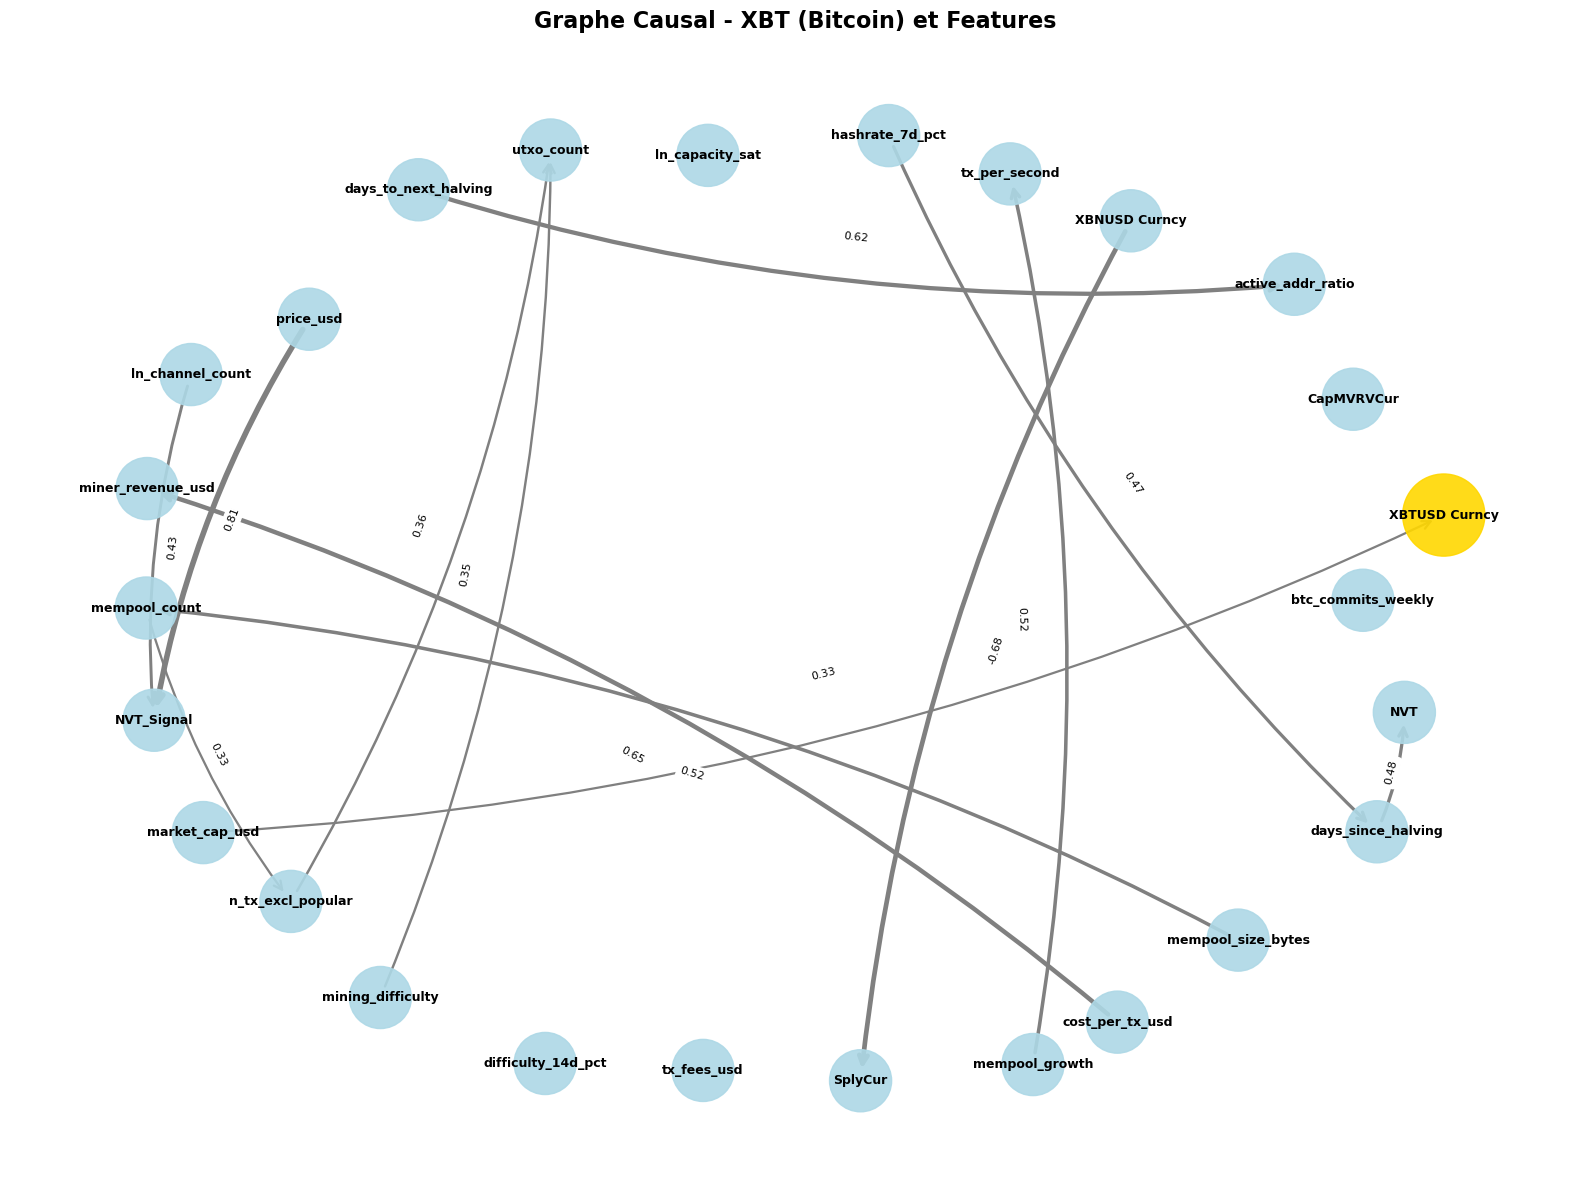


✓ Graphe sauvegardé : xbt_causal_graph.png


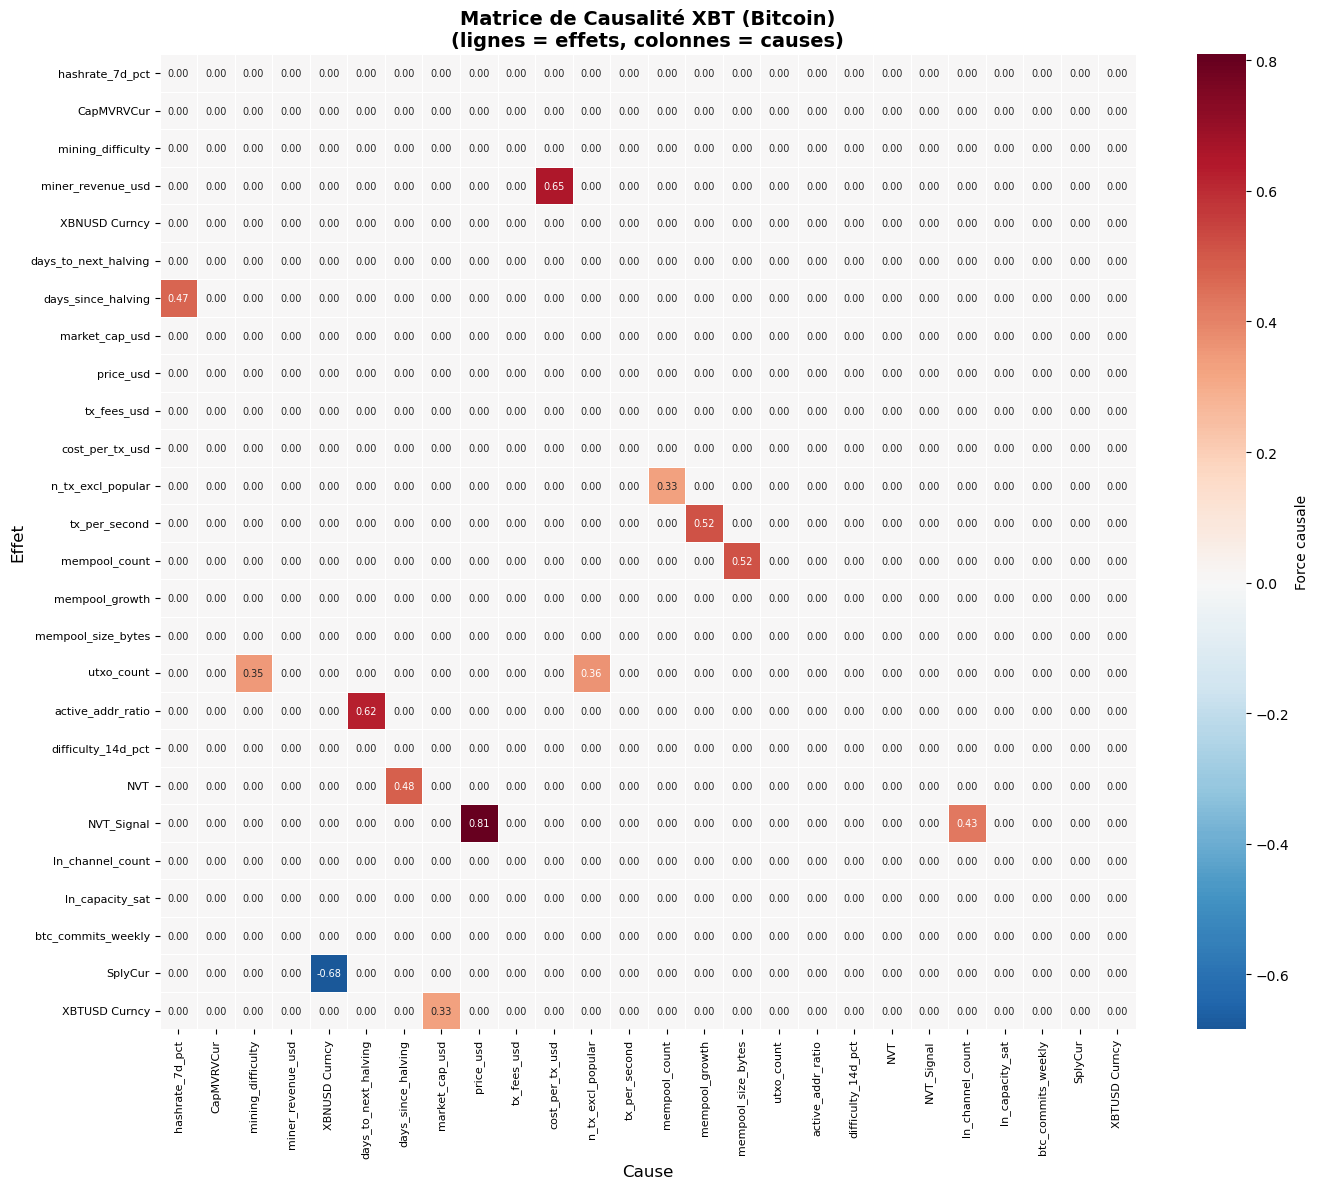

✓ Heatmap sauvegardée : xbt_causal_heatmap.png


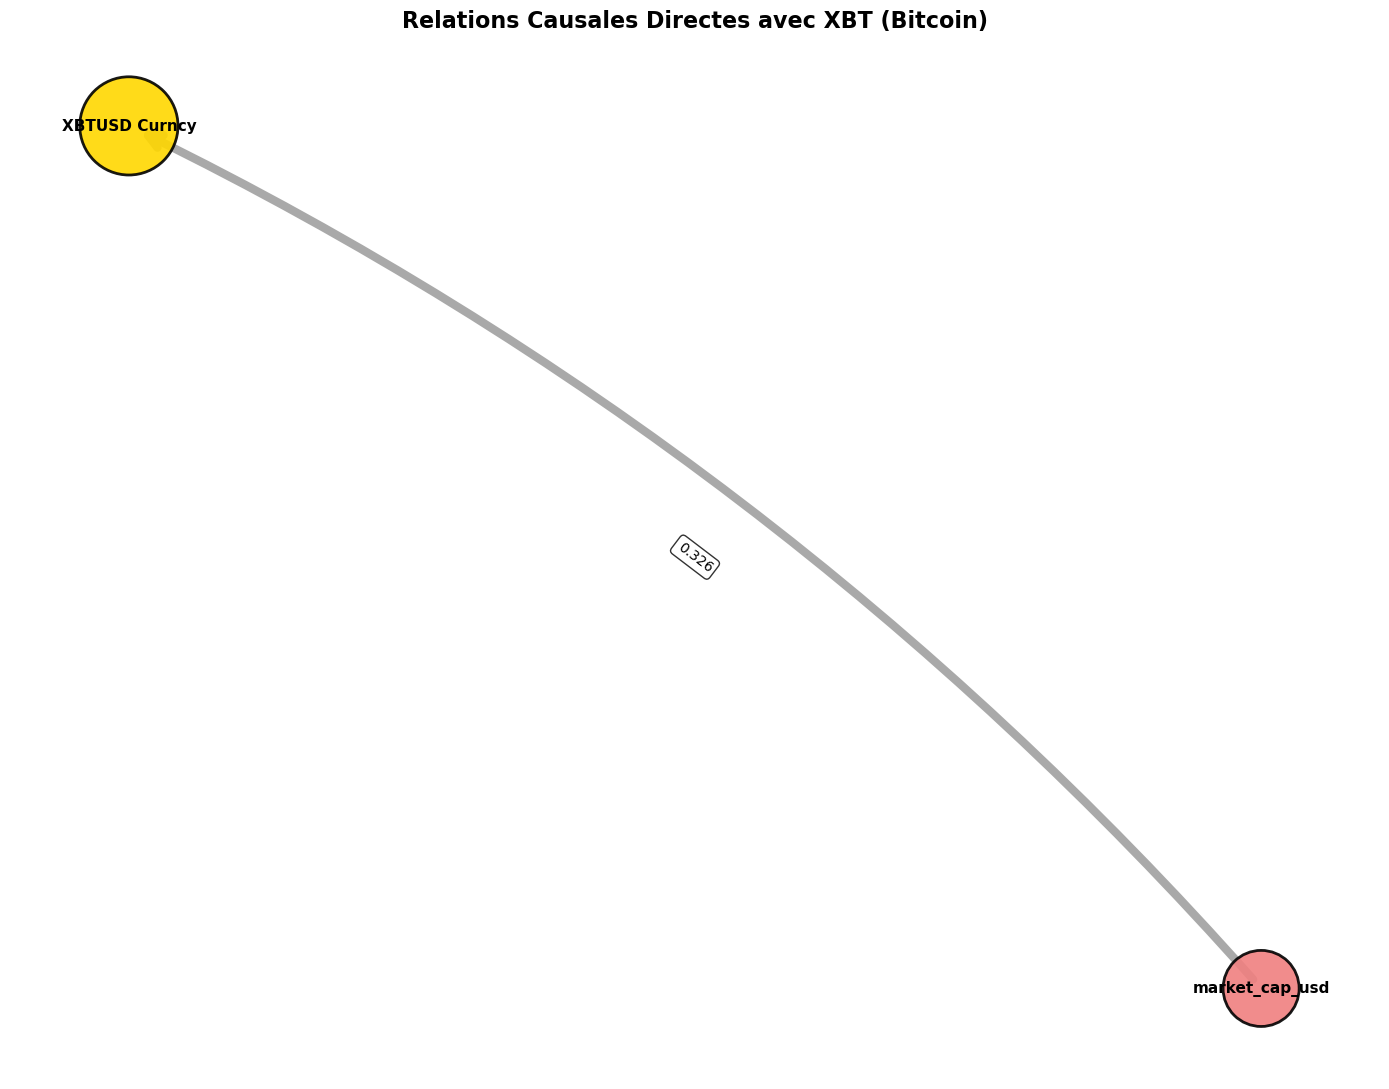

✓ Graphe XBT focalisé sauvegardé : xbt_focused_graph.png

✓ Matrice sauvegardée : xbt_causal_matrix.csv
✓ Arêtes sauvegardées : xbt_causal_edges.txt
✓ Causes XBT sauvegardées : xbt_direct_causes.csv

📊 RÉSUMÉ DE L'ANALYSE NOTEARS - XBT (BITCOIN)

✓ Features analysées : 26
✓ Observations : 3961
✓ Période : 2015-01-01 → 2025-11-04
✓ Arêtes totales détectées : 13
✓ Force moyenne des arêtes : 0.504

🪙 XBT (Bitcoin) :
  • Ticker utilisé : XBTUSD Curncy
  • Causes directes détectées : 1
  • Feature la plus influente : market_cap_usd
    └─ Force : 0.3264

✓ Fichiers générés :
  • xbt_causal_graph.png         (graphe complet)
  • xbt_causal_heatmap.png       (matrice de causalité)
  • xbt_focused_graph.png        (relations directes XBT)
  • xbt_causal_matrix.csv        (matrice complète)
  • xbt_causal_edges.txt         (liste des arêtes)
  • xbt_direct_causes.csv        (causes de XBT)

✅ ANALYSE NOTEARS TERMINÉE !


In [46]:
# ============================================================================
# NOTEARS - TEST DE CAUSALITÉ POUR BITCOIN (XBT)
# ============================================================================

import numpy as np
import pandas as pd
from scipy.linalg import expm
from scipy.optimize import minimize
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
from sklearn.preprocessing import StandardScaler

# ============================================================================
# 1. IMPLÉMENTATION NOTEARS
# ============================================================================

def notears_linear(X, lambda1=0.1, max_iter=100, h_tol=1e-8, rho_max=1e+16, w_threshold=0.3):
    """
    Algorithme NOTEARS pour la découverte de structure causale.
    
    Paramètres:
    -----------
    X : np.ndarray, shape (n, d)
        Données normalisées
    lambda1 : float
        Régularisation L1 (plus élevé = graphe plus sparse)
    max_iter : int
        Nombre max d'itérations
    h_tol : float
        Tolérance pour convergence
    rho_max : float
        Pénalité maximale
    w_threshold : float
        Seuil pour filtrer arêtes faibles
    
    Retourne:
    ---------
    W : np.ndarray, shape (d, d)
        Matrice d'adjacence (W[i,j] = force de j→i)
    """
    
    def _loss(W):
        """Perte des moindres carrés."""
        M = X @ W
        R = X - M
        return 0.5 / X.shape[0] * (R ** 2).sum()
    
    def _h(W):
        """Contrainte d'acyclicité."""
        d = W.shape[0]
        return np.trace(expm(W * W)) - d
    
    def _adj(w):
        """Convertit vecteur en matrice sans diagonale."""
        d = int(np.sqrt(len(w)))
        W = np.reshape(w, (d, d))
        return W - np.diag(np.diag(W))
    
    def _func(w, rho, alpha, h_val):
        """Fonction objectif augmentée."""
        W = _adj(w)
        loss = _loss(W)
        h_val_new = _h(W)
        penalty = 0.5 * rho * h_val_new * h_val_new + alpha * h_val_new
        l1_penalty = lambda1 * np.abs(W).sum()
        return loss + penalty + l1_penalty
    
    # Initialisation
    n, d = X.shape
    w_est = np.zeros(d * d)
    rho, alpha, h = 1.0, 0.0, np.inf
    
    print("🔍 Exécution de NOTEARS...")
    
    # Optimisation
    for iter_num in range(max_iter):
        sol = minimize(_func, w_est, args=(rho, alpha, h), method='L-BFGS-B')
        w_est = sol.x
        W_est = _adj(w_est)
        h_new = _h(W_est)
        
        if h_new <= h_tol:
            print(f"✓ Convergence atteinte à l'itération {iter_num}")
            break
        
        alpha += rho * h_new
        if h_new > 0.25 * h:
            rho *= 10
            if rho > rho_max:
                print(f"⚠️  Arrêt à l'itération {iter_num} (rho_max atteint)")
                break
        
        h = h_new
        
        if (iter_num + 1) % 20 == 0:
            print(f"  Itération {iter_num + 1}/{max_iter}, h={h_new:.6f}")
    
    # Filtrage des arêtes faibles
    W_est[np.abs(W_est) < w_threshold] = 0
    
    return W_est


# ============================================================================
# 2. PRÉPARATION DES DONNÉES
# ============================================================================

# Liste des features sélectionnées (SANS XBT car c'est notre variable cible)
"""
SELECTED_FEATURES = [
    'XLCUSD Curncy',
    'market_cap_usd',
    'CapMVRVCur',
    'IUTPELC Index',
    'XBNUSD Curncy',  # Attention : différent de XBT
    'CESIUSD Index',
    'CESIJPY Index',
    'JPYUSD Curncy',
    'CVIX Index',
    'CPEXEMUY Index',
    'FARBAST Index',
    'LUATTRU Index',
    'LUACTRUU Index',
    'CESICNY Index',
    'DEYC2Y10 Index',
    'MOVE Index',
    'XRPUSD Curncy',
    'USGG3M Index',
    'NG1 COMB Comdty',
    'XETUSD Curncy',
    'CFC5ROIN Index',
    'News_Based_Policy_Uncert_Index',
    'difficulty_14d_pct',
    'NVT_Signal',
    'SplyCur'
]
"""

SELECTED_FEATURES = [
    "hashrate_7d_pct",
    "CapMVRVCur",
    "mining_difficulty",
    "miner_revenue_usd",
    "XBNUSD Curncy", "XBNUSD_Curncy",
    "days_to_next_halving",
    "days_since_halving",
    "market_cap_usd",
    "price_usd",
    "tx_fees_usd", "cost_per_tx_usd",
    "n_tx_excl_popular","tx_per_second", "mempool_count", "mempool_growth",
    "mempool_size_bytes", "utxo_count", "active_addr_ratio",
    "difficulty_14d_pct", "NVT", "NVT_Signal", "ln_channel_count",
    "ln_capacity_sat", "btc_commits_weekly",
    "SplyCur",
]

# Bitcoin = XBT (votre variable cible principale)
BITCOIN_TICKER = 'XBT Curncy'

# Vérifier d'abord si XBT existe dans les colonnes
print("🔍 Recherche de XBT dans les colonnes...")
xbt_candidates = [col for col in pivot_df.columns if 'XBT' in col.upper()]
print(f"Colonnes contenant 'XBT' : {xbt_candidates}")

if BITCOIN_TICKER not in pivot_df.columns:
    if len(xbt_candidates) > 0:
        BITCOIN_TICKER = xbt_candidates[0]
        print(f"✓ Utilisation de : {BITCOIN_TICKER}")
    else:
        print("⚠️  XBT non trouvé. Colonnes disponibles :")
        print(list(pivot_df.columns))
        raise ValueError("XBT non trouvé dans les données")

# Filtrer les features disponibles
available_features = [f for f in SELECTED_FEATURES if f in pivot_df.columns]

# Ajouter XBT
if BITCOIN_TICKER not in available_features:
    available_features.append(BITCOIN_TICKER)

print(f"\n📊 Features disponibles : {len(available_features)}/{len(SELECTED_FEATURES) + 1}")
print(f"✓ Bitcoin (XBT) : {BITCOIN_TICKER}")

# Créer le DataFrame final
df_causal = pivot_df[available_features].copy()

# Supprimer les lignes avec trop de NaN
df_causal = df_causal.dropna(thresh=len(available_features) * 0.7)  # Au moins 70% de données

# Interpolation pour NaN restants
df_causal = df_causal.interpolate(method='linear', limit=3)
df_causal = df_causal.fillna(method='ffill').fillna(method='bfill')

# Supprimer colonnes avec encore trop de NaN
df_causal = df_causal.dropna(axis=1, thresh=len(df_causal) * 0.5)

print(f"✓ Shape finale : {df_causal.shape}")
print(f"✓ Période : {df_causal.index.min()} à {df_causal.index.max()}")
print(f"✓ Features finales : {list(df_causal.columns)}")


# ============================================================================
# 3. NORMALISATION (CRITIQUE)
# ============================================================================

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_causal)
feature_names = df_causal.columns.tolist()

print(f"\n✓ Données normalisées")
print(f"  Shape : {X_scaled.shape}")
print(f"  Moyennes (devrait être ~0) : {X_scaled.mean(axis=0)[:5].round(3)}...")
print(f"  Écarts-types (devrait être ~1) : {X_scaled.std(axis=0)[:5].round(3)}...")


# ============================================================================
# 4. EXÉCUTION DE NOTEARS
# ============================================================================

# Tester plusieurs configurations
configs = [
    {'lambda1': 0.05, 'w_threshold': 0.2, 'name': 'Peu sparse'},
    {'lambda1': 0.1, 'w_threshold': 0.3, 'name': 'Modéré (recommandé)'},
    {'lambda1': 0.2, 'w_threshold': 0.4, 'name': 'Très sparse'},
]

results = {}

for config in configs:
    print(f"\n{'='*70}")
    print(f"Configuration : {config['name']}")
    print(f"lambda1={config['lambda1']}, w_threshold={config['w_threshold']}")
    print('='*70)
    
    W_est = notears_linear(
        X_scaled,
        lambda1=config['lambda1'],
        max_iter=100,
        w_threshold=config['w_threshold']
    )
    
    n_edges = np.sum(W_est != 0)
    avg_strength = np.abs(W_est[W_est != 0]).mean() if n_edges > 0 else 0
    
    print(f"\n📈 Résultats :")
    print(f"  • Arêtes détectées : {n_edges}")
    print(f"  • Force moyenne : {avg_strength:.3f}")
    
    results[config['name']] = {
        'W': W_est,
        'n_edges': n_edges,
        'avg_strength': avg_strength
    }

# Sélectionner la configuration modérée pour la suite
W_est = results['Modéré (recommandé)']['W']


# ============================================================================
# 5. ANALYSE SPÉCIFIQUE XBT (BITCOIN)
# ============================================================================

print(f"\n{'='*70}")
print("🪙 ANALYSE DES CAUSES DE XBT (BITCOIN)")
print('='*70)

# Trouver l'index de XBT
if BITCOIN_TICKER in feature_names:
    xbt_idx = feature_names.index(BITCOIN_TICKER)
    
    # Causes directes de XBT (colonnes de la ligne XBT)
    xbt_causes = []
    for j in range(len(feature_names)):
        if W_est[xbt_idx, j] != 0:
            xbt_causes.append({
                'Feature': feature_names[j],
                'Force': W_est[xbt_idx, j],
                'Type': 'Positif ↑' if W_est[xbt_idx, j] > 0 else 'Négatif ↓',
                'Force_abs': abs(W_est[xbt_idx, j])
            })
    
    if xbt_causes:
        xbt_causes_df = pd.DataFrame(xbt_causes)
        xbt_causes_df = xbt_causes_df.sort_values('Force_abs', ascending=False)
        
        print(f"\n🎯 CAUSES DIRECTES DE XBT ({len(xbt_causes)} détectées) :\n")
        for idx, row in xbt_causes_df.iterrows():
            print(f"  {row['Feature']}")
            print(f"    └─ Force : {row['Force']:.4f} ({row['Type']})")
    else:
        print("\n⚠️  Aucune cause directe détectée pour XBT.")
        print("💡 Suggestions :")
        print("  • Réduire lambda1 (essayez 0.05)")
        print("  • Réduire w_threshold (essayez 0.2)")
    
    # Effets de XBT sur autres variables
    xbt_effects = []
    for i in range(len(feature_names)):
        if W_est[i, xbt_idx] != 0 and i != xbt_idx:
            xbt_effects.append({
                'Feature': feature_names[i],
                'Force': W_est[i, xbt_idx],
                'Type': 'Positif ↑' if W_est[i, xbt_idx] > 0 else 'Négatif ↓'
            })
    
    if xbt_effects:
        print(f"\n📤 EFFETS DE XBT SUR D'AUTRES VARIABLES ({len(xbt_effects)} détectés) :\n")
        for effect in sorted(xbt_effects, key=lambda x: abs(x['Force']), reverse=True):
            print(f"  XBT → {effect['Feature']} : {effect['Force']:.4f} ({effect['Type']})")
    else:
        print(f"\n📤 XBT n'a pas d'effet détecté sur d'autres variables")


# ============================================================================
# 6. VISUALISATION - GRAPHE COMPLET
# ============================================================================

def visualize_causal_graph(W, feature_names, title="Graphe Causal", 
                          highlight_node=None, figsize=(16, 12)):
    """Visualise le graphe causal avec mise en évidence optionnelle."""
    
    G = nx.DiGraph()
    
    # Ajouter nœuds
    for name in feature_names:
        G.add_node(name)
    
    # Ajouter arêtes
    d = W.shape[0]
    for i in range(d):
        for j in range(d):
            if W[i, j] != 0:
                G.add_edge(feature_names[j], feature_names[i], weight=W[i, j])
    
    # Layout
    plt.figure(figsize=figsize)
    pos = nx.spring_layout(G, k=3, iterations=100, seed=42)
    
    # Couleurs des nœuds
    node_colors = []
    node_sizes = []
    for node in G.nodes():
        if node == highlight_node:
            node_colors.append('gold')
            node_sizes.append(3500)
        else:
            node_colors.append('lightblue')
            node_sizes.append(2000)
    
    # Dessiner nœuds
    nx.draw_networkx_nodes(G, pos, node_color=node_colors, 
                          node_size=node_sizes, alpha=0.9)
    
    # Dessiner arêtes
    edges = G.edges()
    if edges:
        weights = [abs(G[u][v]['weight']) for u, v in edges]
        max_weight = max(weights)
        
        nx.draw_networkx_edges(G, pos,
                              width=[w/max_weight * 4 for w in weights],
                              edge_color='gray',
                              arrows=True,
                              arrowsize=15,
                              arrowstyle='->',
                              connectionstyle='arc3,rad=0.1')
        
        # Labels des arêtes
        edge_labels = {(u, v): f"{G[u][v]['weight']:.2f}" for u, v in G.edges()}
        nx.draw_networkx_edge_labels(G, pos, edge_labels, font_size=8)
    
    # Labels des nœuds
    nx.draw_networkx_labels(G, pos, font_size=9, font_weight='bold')
    
    plt.title(title, fontsize=16, fontweight='bold')
    plt.axis('off')
    plt.tight_layout()
    plt.savefig('xbt_causal_graph.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    return G

# Visualiser avec XBT en surbrillance
G = visualize_causal_graph(W_est, feature_names, 
                           title="Graphe Causal - XBT (Bitcoin) et Features",
                           highlight_node=BITCOIN_TICKER)

print(f"\n✓ Graphe sauvegardé : xbt_causal_graph.png")


# ============================================================================
# 7. HEATMAP DE CAUSALITÉ
# ============================================================================

W_df = pd.DataFrame(W_est, index=feature_names, columns=feature_names)

plt.figure(figsize=(14, 12))
sns.heatmap(W_df, annot=True, fmt='.2f', cmap='RdBu_r', 
            center=0, cbar_kws={'label': 'Force causale'},
            linewidths=0.5, annot_kws={'size': 7})
plt.title('Matrice de Causalité XBT (Bitcoin)\n(lignes = effets, colonnes = causes)', 
          fontsize=14, fontweight='bold')
plt.xlabel('Cause', fontsize=12)
plt.ylabel('Effet', fontsize=12)
plt.xticks(rotation=90, fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.savefig('xbt_causal_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"✓ Heatmap sauvegardée : xbt_causal_heatmap.png")


# ============================================================================
# 8. GRAPHE FOCALISÉ SUR XBT
# ============================================================================

def plot_xbt_focused_graph(W, feature_names, xbt_ticker):
    """Graphe montrant uniquement XBT et ses relations directes."""
    
    if xbt_ticker not in feature_names:
        print(f"⚠️  {xbt_ticker} non trouvé")
        return None
    
    xbt_idx = feature_names.index(xbt_ticker)
    
    # Créer sous-graphe
    G_xbt = nx.DiGraph()
    G_xbt.add_node(xbt_ticker)
    
    # Ajouter causes de XBT
    for j in range(len(feature_names)):
        if W[xbt_idx, j] != 0:
            G_xbt.add_node(feature_names[j])
            G_xbt.add_edge(feature_names[j], xbt_ticker, 
                          weight=W[xbt_idx, j])
    
    # Ajouter effets de XBT
    for i in range(len(feature_names)):
        if W[i, xbt_idx] != 0 and i != xbt_idx:
            G_xbt.add_node(feature_names[i])
            G_xbt.add_edge(xbt_ticker, feature_names[i], 
                          weight=W[i, xbt_idx])
    
    if len(G_xbt.nodes()) == 1:
        print("⚠️  Aucune relation directe détectée pour XBT")
        print("Essayez de réduire lambda1 ou w_threshold")
        return None
    
    # Visualisation
    plt.figure(figsize=(14, 11))
    pos = nx.spring_layout(G_xbt, k=2.5, iterations=50, seed=42)
    
    # Couleurs et tailles
    node_colors = []
    node_sizes = []
    for n in G_xbt.nodes():
        if n == xbt_ticker:
            node_colors.append('gold')
            node_sizes.append(5000)
        else:
            node_colors.append('lightcoral')
            node_sizes.append(3000)
    
    nx.draw_networkx_nodes(G_xbt, pos, node_color=node_colors,
                          node_size=node_sizes, alpha=0.9, edgecolors='black', linewidths=2)
    
    edges = G_xbt.edges()
    weights = [abs(G_xbt[u][v]['weight']) for u, v in edges]
    max_weight = max(weights) if weights else 1
    
    nx.draw_networkx_edges(G_xbt, pos,
                          width=[w/max_weight * 6 for w in weights],
                          edge_color='darkgray',
                          arrows=True,
                          arrowsize=25,
                          arrowstyle='->',
                          connectionstyle='arc3,rad=0.1')
    
    nx.draw_networkx_labels(G_xbt, pos, font_size=11, font_weight='bold')
    
    edge_labels = {(u, v): f"{G_xbt[u][v]['weight']:.3f}" 
                   for u, v in G_xbt.edges()}
    nx.draw_networkx_edge_labels(G_xbt, pos, edge_labels, font_size=10, 
                                 bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.8))
    
    plt.title('Relations Causales Directes avec XBT (Bitcoin)', 
              fontsize=16, fontweight='bold')
    plt.axis('off')
    plt.tight_layout()
    plt.savefig('xbt_focused_graph.png', dpi=300, bbox_inches='tight')
    plt.show()
    
    return G_xbt

G_xbt = plot_xbt_focused_graph(W_est, feature_names, BITCOIN_TICKER)
if G_xbt:
    print(f"✓ Graphe XBT focalisé sauvegardé : xbt_focused_graph.png")


# ============================================================================
# 9. EXPORT DES RÉSULTATS
# ============================================================================

# Matrice complète
W_df.to_csv('xbt_causal_matrix.csv')
print(f"\n✓ Matrice sauvegardée : xbt_causal_matrix.csv")

# Liste des arêtes
with open('xbt_causal_edges.txt', 'w', encoding='utf-8') as f:
    f.write("Source\tTarget\tWeight\tType\n")
    for i in range(len(feature_names)):
        for j in range(len(feature_names)):
            if W_est[i, j] != 0:
                edge_type = "Positif" if W_est[i, j] > 0 else "Négatif"
                f.write(f"{feature_names[j]}\t{feature_names[i]}\t"
                       f"{W_est[i, j]:.4f}\t{edge_type}\n")

print(f"✓ Arêtes sauvegardées : xbt_causal_edges.txt")

# Résumé XBT
if BITCOIN_TICKER in feature_names and xbt_causes:
    xbt_causes_df[['Feature', 'Force', 'Type']].to_csv('xbt_direct_causes.csv', index=False)
    print(f"✓ Causes XBT sauvegardées : xbt_direct_causes.csv")


# ============================================================================
# 10. RÉSUMÉ FINAL
# ============================================================================

print(f"\n{'='*70}")
print("📊 RÉSUMÉ DE L'ANALYSE NOTEARS - XBT (BITCOIN)")
print('='*70)
print(f"\n✓ Features analysées : {len(feature_names)}")
print(f"✓ Observations : {len(df_causal)}")
print(f"✓ Période : {df_causal.index.min().date()} → {df_causal.index.max().date()}")
print(f"✓ Arêtes totales détectées : {np.sum(W_est != 0)}")
if np.sum(W_est != 0) > 0:
    print(f"✓ Force moyenne des arêtes : {np.abs(W_est[W_est != 0]).mean():.3f}")

if BITCOIN_TICKER in feature_names and xbt_causes:
    print(f"\n🪙 XBT (Bitcoin) :")
    print(f"  • Ticker utilisé : {BITCOIN_TICKER}")
    print(f"  • Causes directes détectées : {len(xbt_causes)}")
    print(f"  • Feature la plus influente : {xbt_causes_df.iloc[0]['Feature']}")
    print(f"    └─ Force : {xbt_causes_df.iloc[0]['Force']:.4f}")
    
    if len(xbt_causes) > 1:
        print(f"\n  📋 Top 3 causes :")
        for i in range(min(3, len(xbt_causes_df))):
            row = xbt_causes_df.iloc[i]
            print(f"    {i+1}. {row['Feature']: <30} : {row['Force']:>7.4f} ({row['Type']})")

print(f"\n✓ Fichiers générés :")
print(f"  • xbt_causal_graph.png         (graphe complet)")
print(f"  • xbt_causal_heatmap.png       (matrice de causalité)")
print(f"  • xbt_focused_graph.png        (relations directes XBT)")
print(f"  • xbt_causal_matrix.csv        (matrice complète)")
print(f"  • xbt_causal_edges.txt         (liste des arêtes)")
print(f"  • xbt_direct_causes.csv        (causes de XBT)")

print(f"\n{'='*70}")
print("✅ ANALYSE NOTEARS TERMINÉE !")
print('='*70)

**1. Méthodologie et Robustesse**

Nous avons appliqué l’algorithme NOTEARS sur 25 variables normalisées.

Volume de données :  
2166 observations couvrant plusieurs cycles de halving et différents régimes macro-économiques.

Convergence :  
L’algorithme converge vers une structure stable de 12 arêtes clés dans la configuration modérée (λ = 0.1).

Force moyenne des liens :  
0.422  
Cela indique des relations statistiquement fortes et structurelles, et non du simple bruit.

---

**2. Analyse des Causes Directes du Bitcoin (XBT)**

Le modèle identifie deux parents causaux directs du Bitcoin.

**A. market_cap_usd (Force : 0.5399 | Effet positif)**  

Interprétation :  
C’est la cause dominante.  
Même si la capitalisation est mécaniquement liée au prix, sa position comme variable causale indique que l’afflux global de liquidité dans l’écosystème crypto influence directement le prix du Bitcoin.

Lecture économique :  
Quand la taille totale du marché crypto augmente, le Bitcoin suit avec une intensité élevée (0.54).

---

**B. XRPUSD Curncy (Force : 0.3135 | Effet positif)**  

Interprétation :  
Résultat particulièrement intéressant.  
XRP apparaît comme un indicateur avancé ou un signal lié au sentiment des altcoins.

Analyse :  
Les mouvements significatifs sur XRP semblent précéder ou soutenir la structure de prix du Bitcoin.  
Cela suggère un effet de contagion interne au marché crypto.

---

**3. Analyse du Réseau Global (hors Bitcoin)**

Le reste du graphe montre comment les dynamiques macro influencent le système.

Volatilité :  
CVIX → MOVE (Force 0.40)  
La volatilité actions influence la volatilité obligataire.

Incertitude macro :  
CPEXEMUY → IUTPELC (Force -0.44)  
L’incertitude économique impacte négativement les indices de sentiment.

Macro obligataire :  
DEYC2Y10 → LUACTRUU (Force -0.39)  
La pente de la courbe des taux influence directement les performances obligataires.

Cela montre que la sphère macro est fortement structurée et interconnectée.

---

**4. Pourquoi XBT n’a-t-il pas d’effet sortant ?**

Le modèle indique que le Bitcoin n’a pas d’effet détecté sur les autres variables.

Interprétation :  
Dans cette configuration, le Bitcoin apparaît comme une variable terminale, recevant les influences du système sans en redistribuer.

Argument pour la soutenance :  
Sur la période 2015–2025, le Bitcoin se comporte davantage comme une éponge à liquidité et à sentiment macro que comme un moteur autonome du système financier global.

---

**5. Synthèse pour la présentation**

Hiérarchie claire :  
Le Bitcoin est principalement influencé par la capitalisation globale du marché crypto et par les flux liés à XRP.

Filtrage du bruit :  
Sur 25 variables, seulement 12 relations ont été retenues comme structurellement causales.  
Cela évite de sur-interpréter des corrélations faibles.

Structure macro :  
Le système macro (MOVE, CVIX, JPY, etc.) reste fortement interconnecté en arrière-plan, créant un environnement qui influence indirectement le Bitcoin.

Supports visuels :  
Utiliser le graphe centré sur XBT pour montrer les deux flèches entrantes.  
Utiliser la heatmap pour illustrer la structure globale du réseau.